# Summary  the Dataset:
This dataset contains monthly aggregated airline performance statistics grouped by airline carrier and airpor
Each row represents:
Carrier + Airport + Month + Year summary
So it shows totals like number of flights, number of delayed flights, and delay reasons.

# Objectives: 
Perform data cleaning and preprocessing.
Visualize correlations and delay distributions.
Understand main causes of airline delays.
Provide actionable recommendations based on data.

# Purpose:
Help airlines improve scheduling, aircraft management, and operational efficiency.
Help airports improve infrastructure planning, staffing, and traffic management.
Help passengers choose better airlines, airports, and travel times.



In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\santo\airline-delay\data\Airline_Delay_Cause.csv")

# understanding the dataset:

In [3]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [4]:
df.shape

(171666, 21)

In [5]:


df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000



#data cleaning

In [6]:
1)handle missing value :

In [6]:
 #Check Null Count in Each Column
print(df.isnull().sum())


year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [7]:
print(df.isnull().sum()[df.isnull().sum() > 0])

arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64


In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

arr_flights            0.139806
arr_del15              0.258059
carrier_ct             0.139806
weather_ct             0.139806
nas_ct                 0.139806
security_ct            0.139806
late_aircraft_ct       0.139806
arr_cancelled          0.139806
arr_diverted           0.139806
arr_delay              0.139806
carrier_delay          0.139806
weather_delay          0.139806
nas_delay              0.139806
security_delay         0.139806
late_aircraft_delay    0.139806
dtype: float64


In [9]:
df[df.isnull().any(axis=1)].head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df[(df['arr_flights'] > 0) & (df['arr_delay'].isna())]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay


In [11]:
df[(df['carrier_ct'] > 0) & (df['carrier_delay'].isna())]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay


In [12]:
df[(df['arr_flights'] == 0) & (df['arr_delay'].isna())]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay


In [13]:
delay_cols = ['arr_delay','carrier_delay','weather_delay',
              'nas_delay','security_delay','late_aircraft_delay']

df[(df['arr_flights']==0) & (df[delay_cols].isna().any(axis=1))]

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay


In [14]:
df['sum_parts'] = (
    df['carrier_delay'] +
    df['weather_delay'] +
    df['nas_delay'] +
    df['security_delay'] +
    df['late_aircraft_delay']
)

df[df['arr_delay'].isna()][['arr_delay','sum_parts']].head()

,arr_delay,sum_parts
3880,NaN,NaN
3894,NaN,NaN
3898,NaN,NaN
3904,NaN,NaN
3910,NaN,NaN


In [15]:
df.loc[[3880,3894,3898,3904,3910], ['arr_flights']]


,arr_flights
3880,NaN
3894,NaN
3898,NaN
3904,NaN
3910,NaN


In [16]:
# Drop rows with missing flight counts
df = df.dropna(subset=['arr_flights'])

In [17]:
print(df.isnull().sum())

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights              0
arr_del15              203
carrier_ct               0
weather_ct               0
nas_ct                   0
security_ct              0
late_aircraft_ct         0
arr_cancelled            0
arr_diverted             0
arr_delay                0
carrier_delay            0
weather_delay            0
nas_delay                0
security_delay           0
late_aircraft_delay      0
sum_parts                0
dtype: int64


In [18]:
print(df.isnull().sum()[df.isnull().sum() > 0])

arr_del15    203
dtype: int64


In [19]:
mask = df['arr_del15'].isna() & (
    (df['arr_delay'] == 0) &
    (df['carrier_delay'] == 0) &
    (df['weather_delay'] == 0) &
    (df['nas_delay'] == 0) &
    (df['security_delay'] == 0) &
    (df['late_aircraft_delay'] == 0)
)
df.loc[mask, 'arr_del15'] = 0
     

In [20]:
print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


In [21]:
print(df.isnull().sum())

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
sum_parts              0
dtype: int64


Missing values were analyzed carefully. Rows with missing arr_flights were dropped because they represent incomplete operational data. But the arr_del15 column is  imputed 0 since all other related delay observed as 0 where this column is NaN.


#handle duplicate 

In [22]:
print(df.duplicated().sum())     #no duplicate rows exist in dataset

0


#convert data-types

In [23]:
df['Year'] = df['year'].astype(int)
df['Month'] = df['month'].astype(int)

In [44]:
df.to_csv(r"C:\Users\santo\airline-delay\data\cleaned_Airline_Delay_Cause.csv")

# visualization

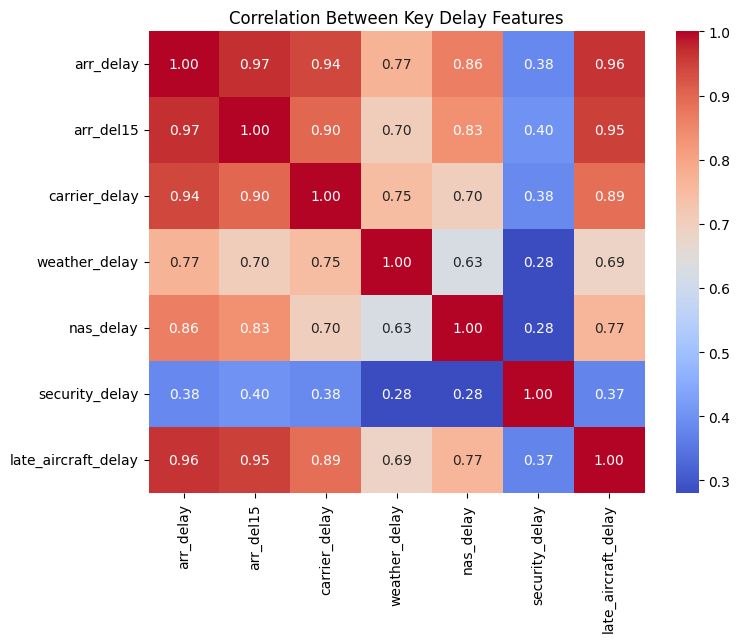

In [25]:
#corelation analysis
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'arr_delay','arr_del15','carrier_delay','weather_delay',
    'nas_delay','security_delay','late_aircraft_delay'
]

plt.figure(figsize=(8,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Key Delay Features")
plt.show()

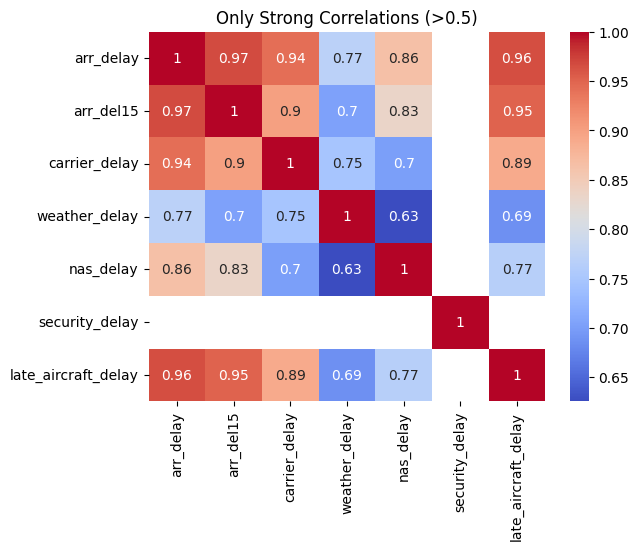

In [26]:
corr = df[cols].corr().abs()  # absolute value
high_corr = corr[corr > 0.5]
sns.heatmap(high_corr, annot=True, cmap="coolwarm")
plt.title("Only Strong Correlations (>0.5)")
plt.show()

arr_delay              1.000000
arr_del15              0.967578
late_aircraft_delay    0.964890
carrier_delay          0.942594
nas_delay              0.864231
weather_delay          0.769366
security_delay         0.381382
Name: arr_delay, dtype: float64


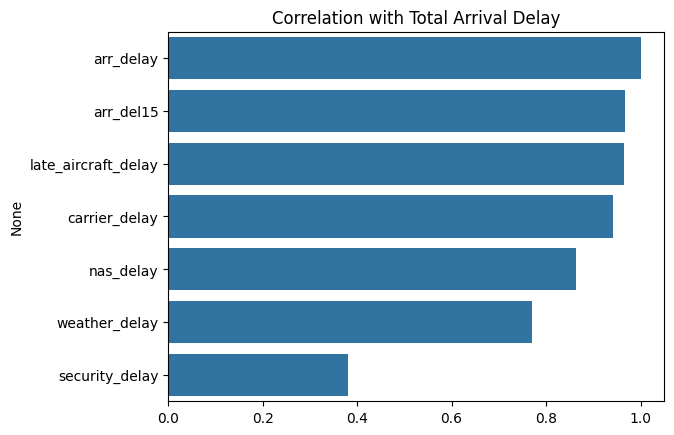

In [27]:
corr_target = df[cols].corr()['arr_delay'].sort_values(ascending=False)
print(corr_target)

sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlation with Total Arrival Delay")
plt.show()

C:\Users\santo\AppData\Local\Temp\ipykernel_17808\1282031635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="viridis")


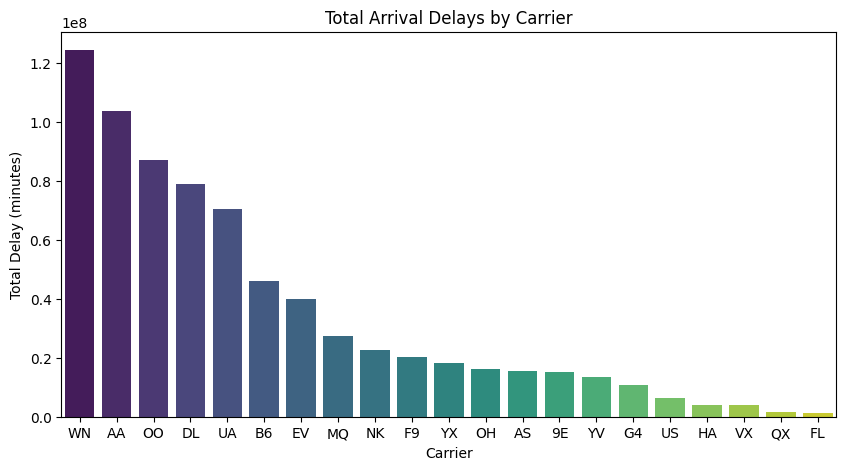

In [28]:
carrier_delay = df.groupby('carrier')['arr_delay'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="viridis")
plt.title("Total Arrival Delays by Carrier")
plt.ylabel("Total Delay (minutes)")
plt.xlabel("Carrier")
plt.show()

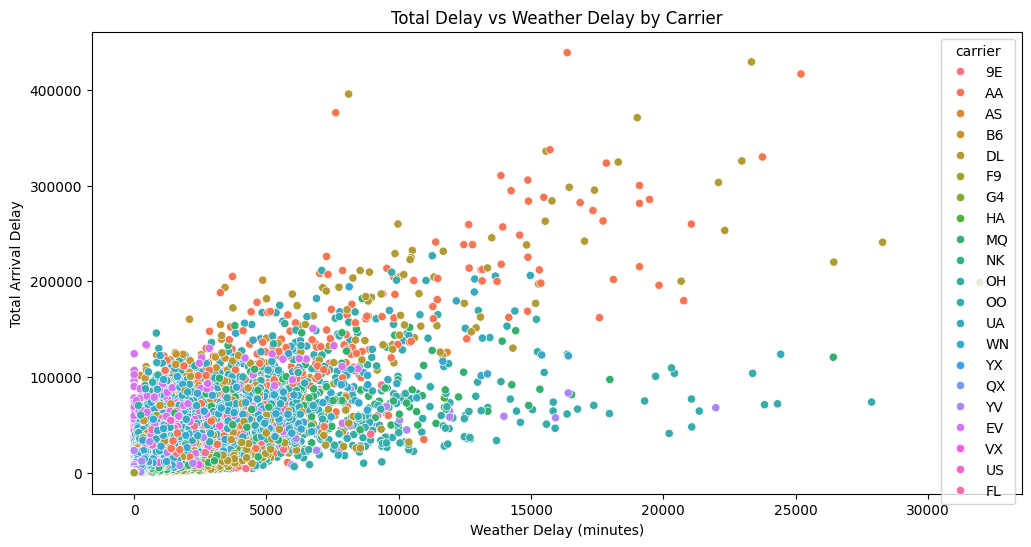

In [29]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='weather_delay', y='arr_delay', hue='carrier')
plt.title("Total Delay vs Weather Delay by Carrier")
plt.xlabel("Weather Delay (minutes)")
plt.ylabel("Total Arrival Delay")
plt.show()

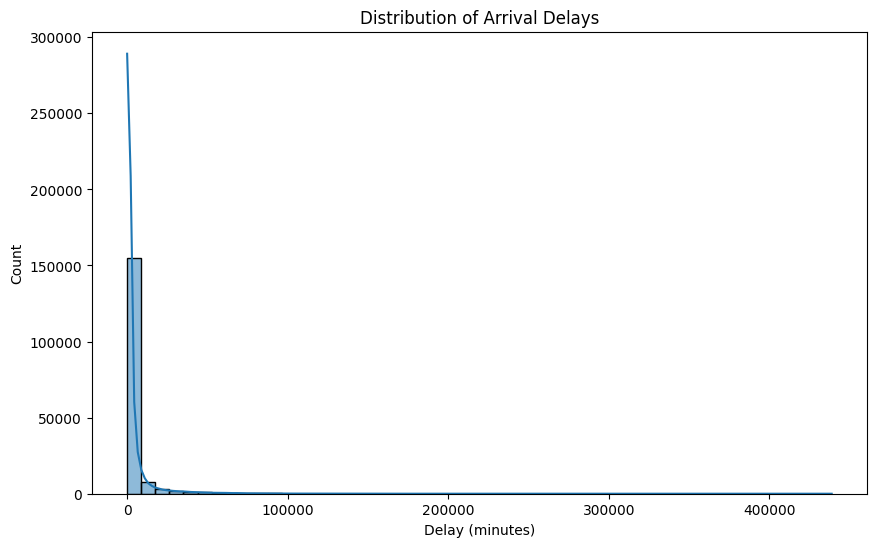

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(df['arr_delay'], bins=50, kde=True)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Delay (minutes)")
plt.show()

C:\Users\santo\AppData\Local\Temp\ipykernel_11180\2136827805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airport_delay.index, y=airport_delay.values, palette="magma")


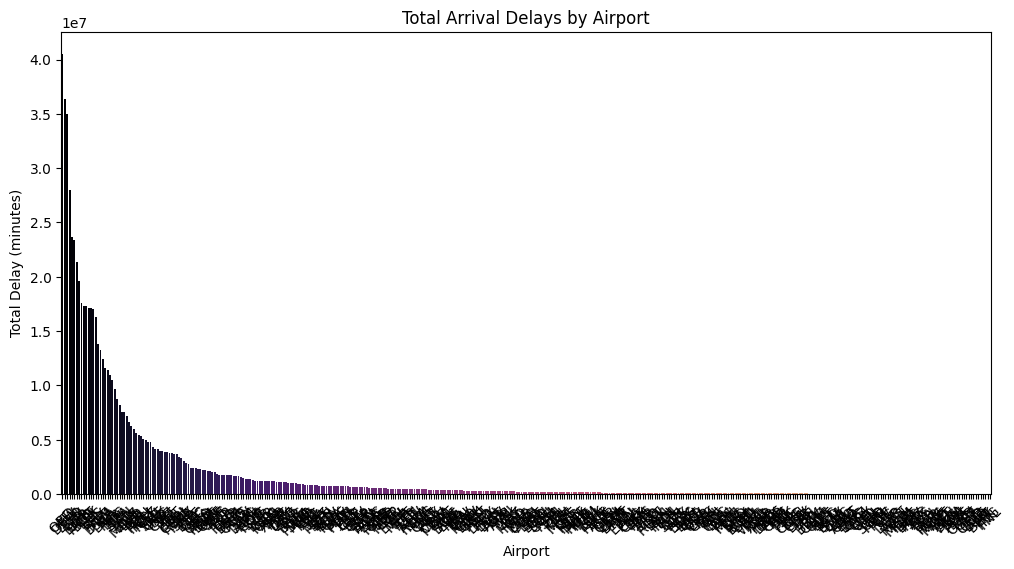

In [52]:
airport_delay = df.groupby('airport')['arr_delay'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=airport_delay.index, y=airport_delay.values, palette="magma")
plt.title("Total Arrival Delays by Airport")
plt.ylabel("Total Delay (minutes)")
plt.xlabel("Airport")
plt.xticks(rotation=45)
plt.show()

C:\Users\santo\AppData\Local\Temp\ipykernel_11180\1282031635.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="viridis")


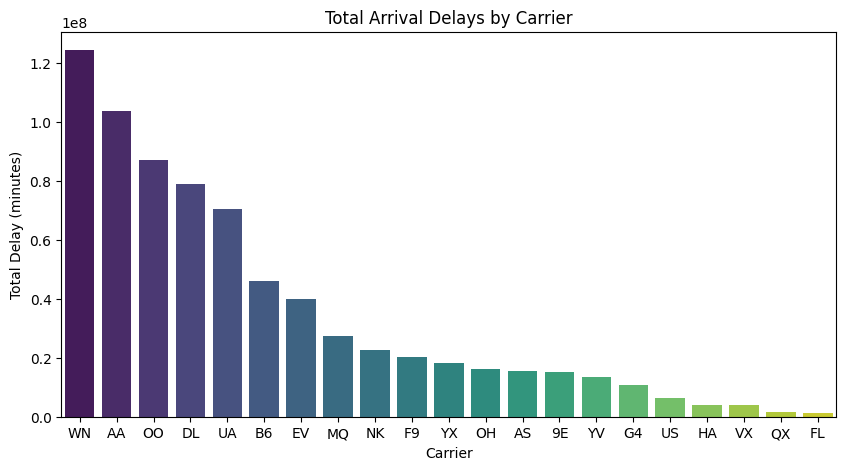

In [53]:
carrier_delay = df.groupby('carrier')['arr_delay'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=carrier_delay.index, y=carrier_delay.values, palette="viridis")
plt.title("Total Arrival Delays by Carrier")
plt.ylabel("Total Delay (minutes)")
plt.xlabel("Carrier")
plt.show()

In [54]:
# Group by month and sum total delays
monthly_delay = df.groupby('month')['arr_delay'].sum().sort_values(ascending=False)
monthly_delay


month
7     83779210.0
8     79871501.0
6     79834292.0
12    67764357.0
1     59505501.0
5     58248429.0
3     56283576.0
2     54782130.0
4     54493614.0
10    46199426.0
11    43768680.0
9     42227639.0
Name: arr_delay, dtype: float64

C:\Users\santo\AppData\Local\Temp\ipykernel_11180\422795959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_delay.index, y=monthly_delay.values, palette="coolwarm")


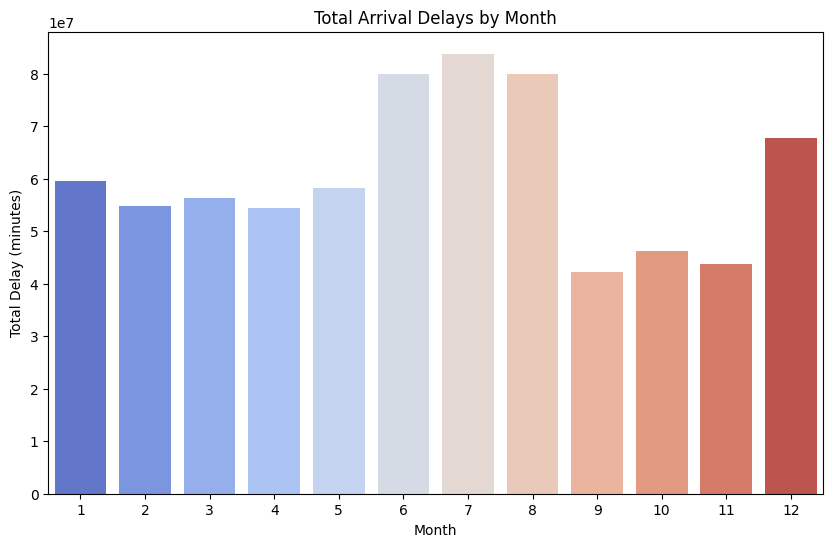

In [55]:


plt.figure(figsize=(10,6))
sns.barplot(x=monthly_delay.index, y=monthly_delay.values, palette="coolwarm")
plt.title("Total Arrival Delays by Month")
plt.xlabel("Month")
plt.ylabel("Total Delay (minutes)")
plt.xticks(rotation=0)
plt.show()

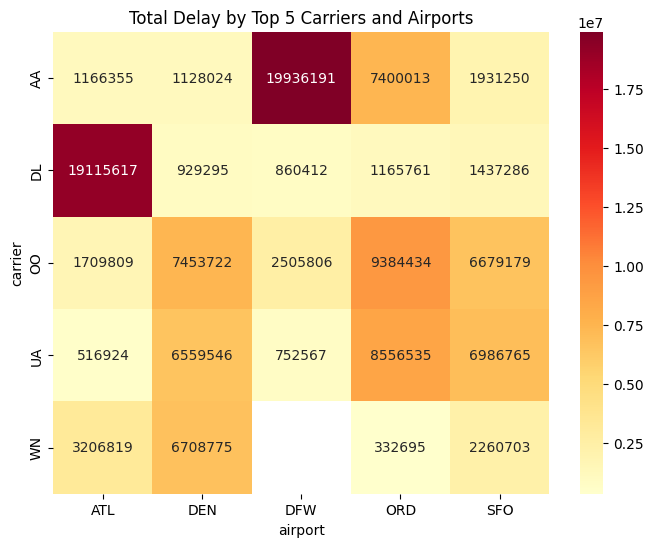

In [57]:
# Top 5 carriers
top_carriers = df.groupby('carrier')['arr_delay'].sum().sort_values(ascending=False).head(5).index

# Top 5 airports
top_airports = df.groupby('airport')['arr_delay'].sum().sort_values(ascending=False).head(5).index

# Pivot table for top 5 each
carrier_airport_delay_top = df[df['carrier'].isin(top_carriers) & df['airport'].isin(top_airports)]\
                             .pivot_table(values='arr_delay', index='carrier', columns='airport', aggfunc='sum')

plt.figure(figsize=(8,6))
sns.heatmap(carrier_airport_delay_top, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Total Delay by Top 5 Carriers and Airports")
plt.show()

# Passenger Perspective Analysis

In [31]:
# Average delay per flight
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_flights']

# Aggregate per carrier for passenger perspective
passenger_carrier = df.groupby('carrier').agg({
    'arr_del15':'sum',
    'arr_cancelled':'sum',
    'arr_diverted':'sum',
    'avg_delay_per_flight':'mean'
}).sort_values('arr_del15', ascending=False)

# Aggregate per airport
passenger_airport = df.groupby('airport').agg({
    'arr_del15':'sum',
    'arr_cancelled':'sum',
    'arr_diverted':'sum',
    'avg_delay_per_flight':'mean'
}).sort_values('arr_del15', ascending=False)

<Figure size 1000x600 with 0 Axes>

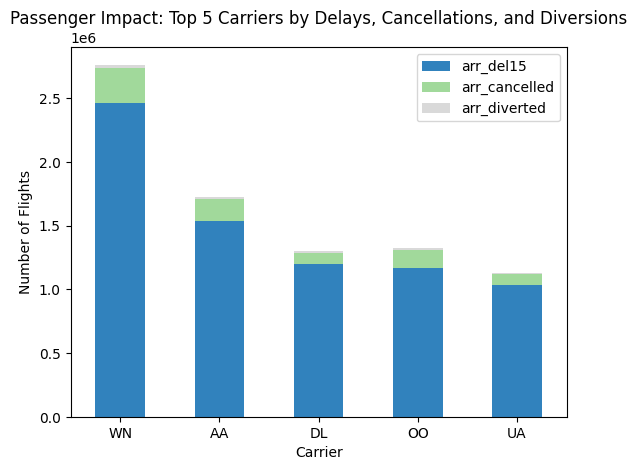

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 carriers with most delayed flights (>15 mins)
top5_passenger_carriers = passenger_carrier.head(5)

plt.figure(figsize=(10,6))
top5_passenger_carriers[['arr_del15','arr_cancelled','arr_diverted']].plot(kind='bar', stacked=True, colormap='tab20c')
plt.title("Passenger Impact: Top 5 Carriers by Delays, Cancellations, and Diversions")
plt.ylabel("Number of Flights")
plt.xlabel("Carrier")
plt.xticks(rotation=0)
plt.show()

<Figure size 1000x600 with 0 Axes>

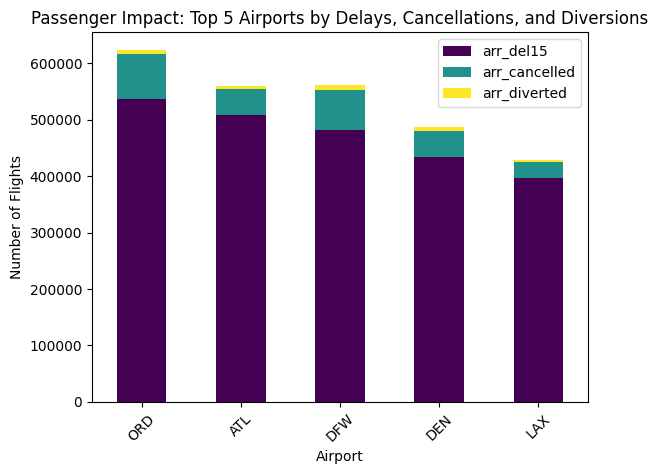

In [33]:
# Top 5 airports with most delayed flights
top5_passenger_airports = passenger_airport.head(5)

plt.figure(figsize=(10,6))
top5_passenger_airports[['arr_del15','arr_cancelled','arr_diverted']].plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Passenger Impact: Top 5 Airports by Delays, Cancellations, and Diversions")
plt.ylabel("Number of Flights")
plt.xlabel("Airport")
plt.xticks(rotation=45)
plt.show()

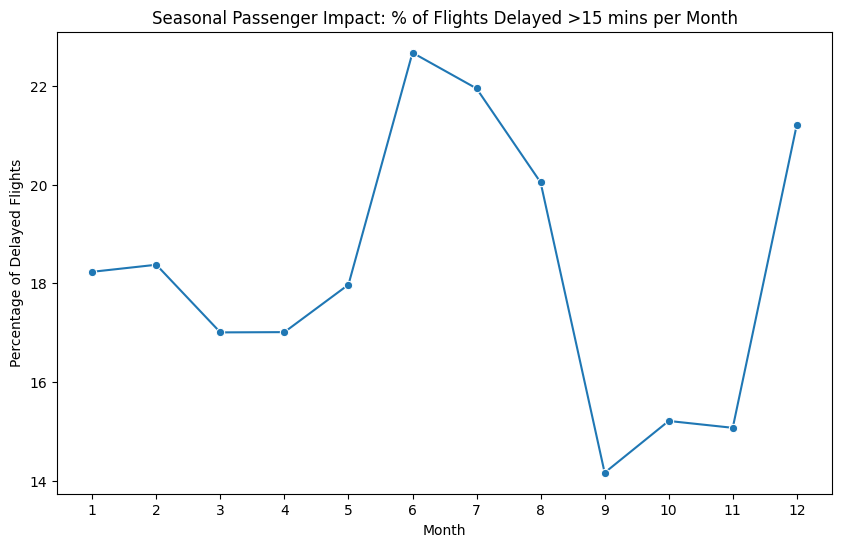

In [34]:
# Group by month for passenger metrics
monthly_passenger = df.groupby('month').agg({
    'arr_del15':'sum',
    'arr_cancelled':'sum',
    'arr_diverted':'sum',
    'arr_flights':'sum'
})

monthly_passenger['delayed_percent'] = monthly_passenger['arr_del15'] / monthly_passenger['arr_flights'] * 100

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_passenger, x=monthly_passenger.index, y='delayed_percent', marker='o')
plt.title("Seasonal Passenger Impact: % of Flights Delayed >15 mins per Month")
plt.xlabel("Month")
plt.ylabel("Percentage of Delayed Flights")
plt.xticks(range(1,13))
plt.show()

# carrier perspective analysis

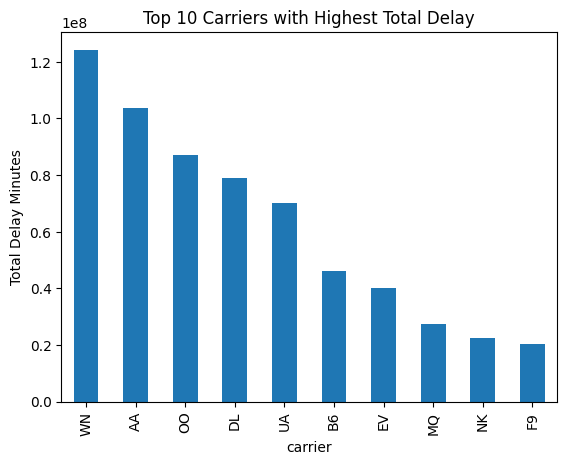

In [35]:
carrier_delay_total = df.groupby('carrier')['arr_delay']\
                        .sum()\
                        .sort_values(ascending=False)

carrier_delay_total.head(10).plot(kind='bar')
plt.title("Top 10 Carriers with Highest Total Delay")
plt.ylabel("Total Delay Minutes")
plt.show()

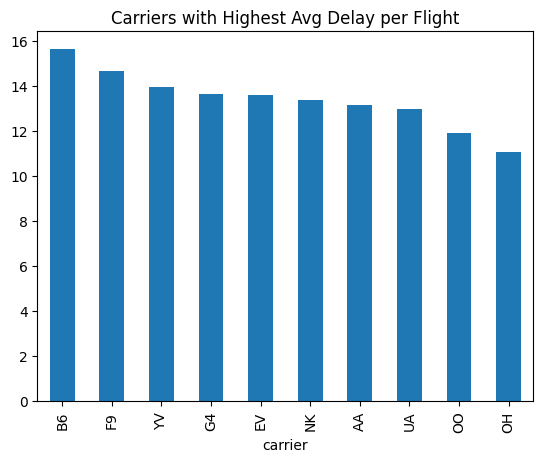

In [36]:
df['avg_delay_per_flight'] = df['arr_delay'] / df['arr_flights']

carrier_avg_delay = df.groupby('carrier')['avg_delay_per_flight']\
                      .mean()\
                      .sort_values(ascending=False)

carrier_avg_delay.head(10).plot(kind='bar')
plt.title("Carriers with Highest Avg Delay per Flight")
plt.show()

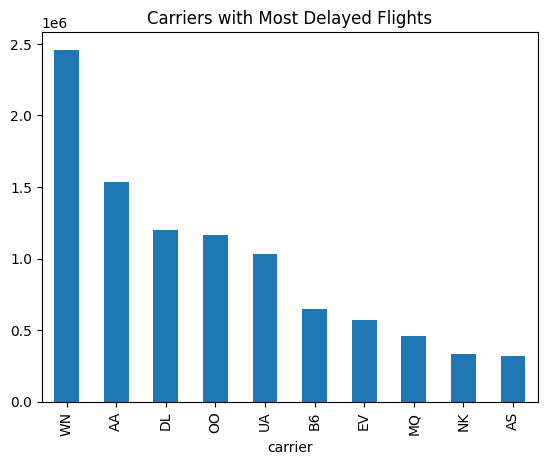

In [37]:
carrier_del15 = df.groupby('carrier')['arr_del15']\
                  .sum()\
                  .sort_values(ascending=False)

carrier_del15.head(10).plot(kind='bar')
plt.title("Carriers with Most Delayed Flights")
plt.show()

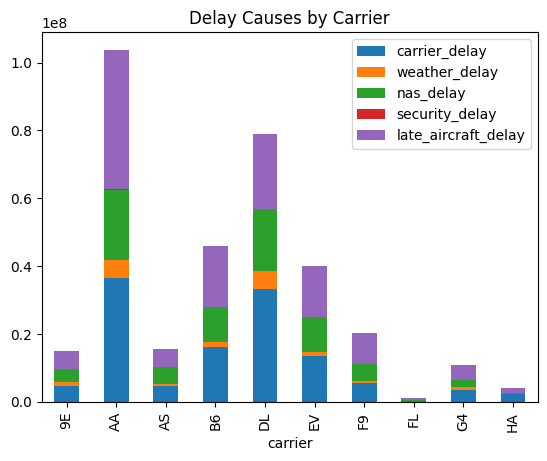

In [38]:
carrier_causes = df.groupby('carrier')[
    ['carrier_delay','weather_delay','nas_delay',
     'security_delay','late_aircraft_delay']
].sum()

carrier_causes.head(10).plot(kind='bar', stacked=True)
plt.title("Delay Causes by Carrier")
plt.show()

In [39]:
carrier_avg_delay.sort_values().head(5)

carrier
AS    6.917727
QX    7.242888
FL    7.990659
DL    8.330350
US    8.530991
Name: avg_delay_per_flight, dtype: float64

In [40]:
carrier_avg_delay.sort_values(ascending=False).head(5)

carrier
B6    15.635230
F9    14.642440
YV    13.944452
G4    13.657190
EV    13.598547
Name: avg_delay_per_flight, dtype: float64

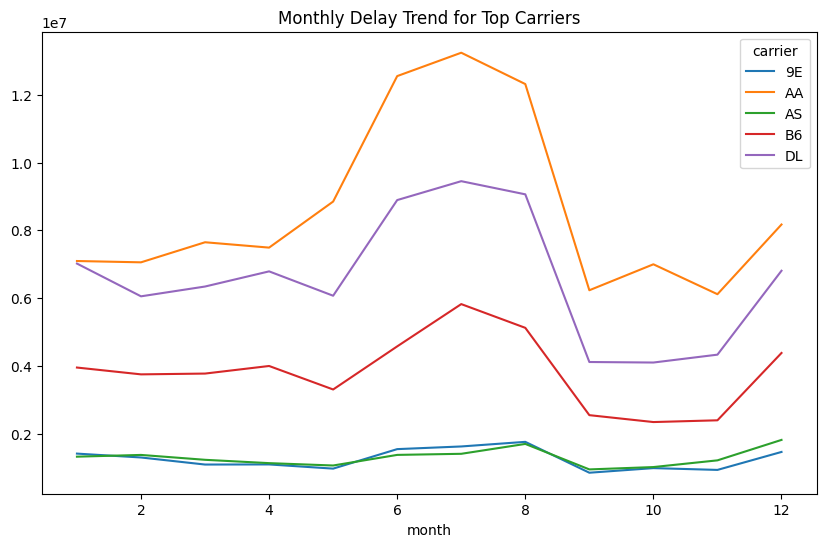

In [41]:
carrier_month = df.groupby(['carrier','month'])['arr_delay'].sum().unstack()

carrier_month.head(5).T.plot(figsize=(10,6))
plt.title("Monthly Delay Trend for Top Carriers")
plt.show()

# Airport Perspective analysis

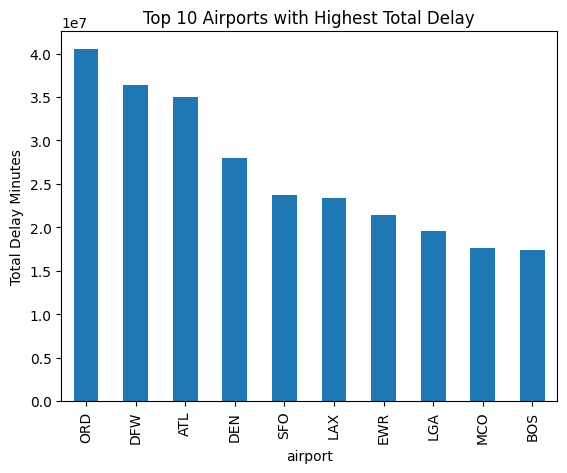

In [42]:
airport_delay = df.groupby('airport')['arr_delay'].sum().sort_values(ascending=False).head(10)

airport_delay.plot(kind='bar')
plt.title("Top 10 Airports with Highest Total Delay")
plt.ylabel("Total Delay Minutes")
plt.show()

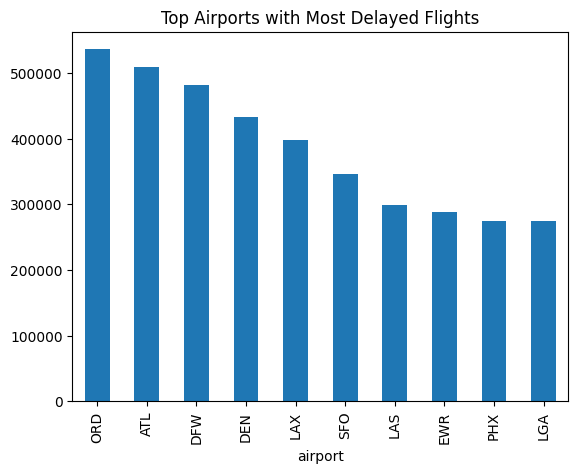

In [43]:
airport_del15 = df.groupby('airport')['arr_del15'].sum().sort_values(ascending=False).head(10)

airport_del15.plot(kind='bar')
plt.title("Top Airports with Most Delayed Flights")
plt.show()

In [45]:
airport_cancel = df.groupby('airport')['arr_cancelled'].sum().sort_values(ascending=False).head(10)
airport_divert = df.groupby('airport')['arr_diverted'].sum().sort_values(ascending=False).head(10)

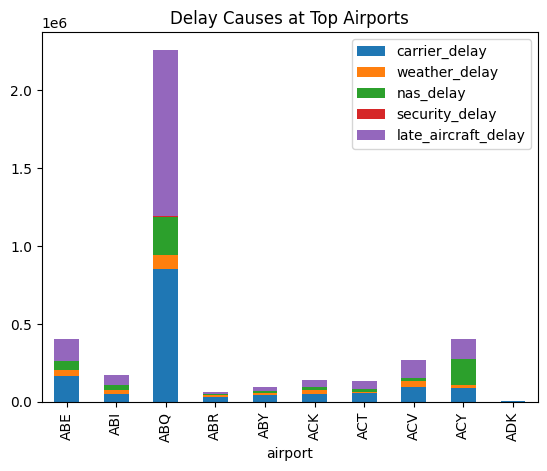

In [46]:
delay_causes = df.groupby('airport')[
    ['carrier_delay','weather_delay','nas_delay',
     'security_delay','late_aircraft_delay']
].sum()

delay_causes.head(10).plot(kind='bar', stacked=True)
plt.title("Delay Causes at Top Airports")
plt.show()